# Task 1: Computer Screen Detection using Hough Line Transform
No lab image was given so first I made a simple lab image with 2 rows of computers (some on, some off, one missing).

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### making the lab image

In [2]:
H, W = 720, 1280
img = np.zeros((H, W, 3), np.uint8)
for y in range(H):
    v = int(200 - 40 * y / H)
    img[y, :] = (v, v + 5, v + 10)   # wall

# desks
cv2.rectangle(img, (0, 330), (W, 360), (40, 75, 120), -1)
cv2.rectangle(img, (0, 560), (W, H), (40, 75, 120), -1)

def monitor(cx, base, mw, mh, on):
    x1, y1 = cx - mw // 2, base - mh - mh // 4
    x2, y2 = x1 + mw, y1 + mh
    cv2.rectangle(img, (cx - mw // 24, y2), (cx + mw // 24, base), (55, 55, 55), -1)   # stand
    cv2.rectangle(img, (cx - mw // 5, base - 6), (cx + mw // 5, base), (55, 55, 55), -1)
    cv2.rectangle(img, (x1, y1), (x2, y2), (25, 25, 25), -1)   # bezel
    b = max(6, mw // 22)
    if on:
        sw, sh = mw - 2 * b, mh - 2 * b
        screen = np.zeros((sh, sw, 3), np.uint8)
        for x in range(sw):
            screen[:, x] = (200 - x * 80 // sw, 120 + x * 60 // sw, 40)
        cv2.rectangle(screen, (int(sw*.1), int(sh*.12)), (int(sw*.6), int(sh*.6)), (245, 245, 245), -1)
        cv2.rectangle(screen, (int(sw*.45), int(sh*.35)), (int(sw*.9), int(sh*.8)), (230, 230, 230), -1)
        cv2.rectangle(screen, (0, int(sh*.9)), (sw, sh), (60, 60, 60), -1)
        img[y1+b:y2-b, x1+b:x2-b] = screen
    else:
        img[y1+b:y2-b, x1+b:x2-b] = (38, 38, 40)

back = [(170, 1), (390, 0), (610, 1), (830, None), (1050, 1)]   # None means no monitor there
front = [(180, 0), (500, 1), (820, 1), (1120, 0)]
for cx, s in back:
    if s is not None: monitor(cx, 345, 170, 105, s)
for cx, s in front:
    if s is not None: monitor(cx, 575, 240, 150, s)

img = cv2.GaussianBlur(img, (3, 3), 0)
noise = np.random.default_rng(7).normal(0, 2, img.shape)
img = np.clip(img + noise, 0, 255).astype(np.uint8)
cv2.imwrite("images/computer_lab.png", img)

# seat positions in the lab (where a screen should be)
seats = {}
for i, (cx, s) in enumerate(back):
    seats["B" + str(i+1)] = (cx, 267)
for i, (cx, s) in enumerate(front):
    seats["F" + str(i+1)] = (cx, 463)

### edges

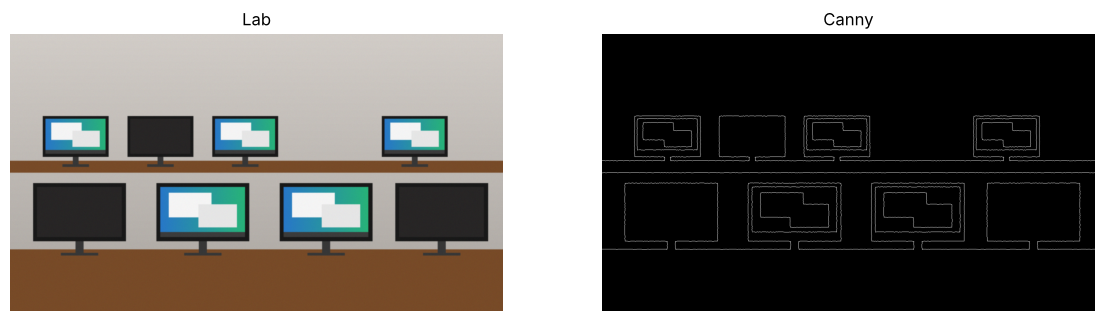

In [3]:
image = cv2.imread("images/computer_lab.png")
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 1.4)
edges = cv2.Canny(blur, 50, 150)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1); plt.imshow(rgb); plt.title("Lab"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(edges, cmap="gray"); plt.title("Canny"); plt.axis("off")
plt.show()

### hough lines
only keeping horizontal and vertical lines because screen borders are like that

lines found: 308


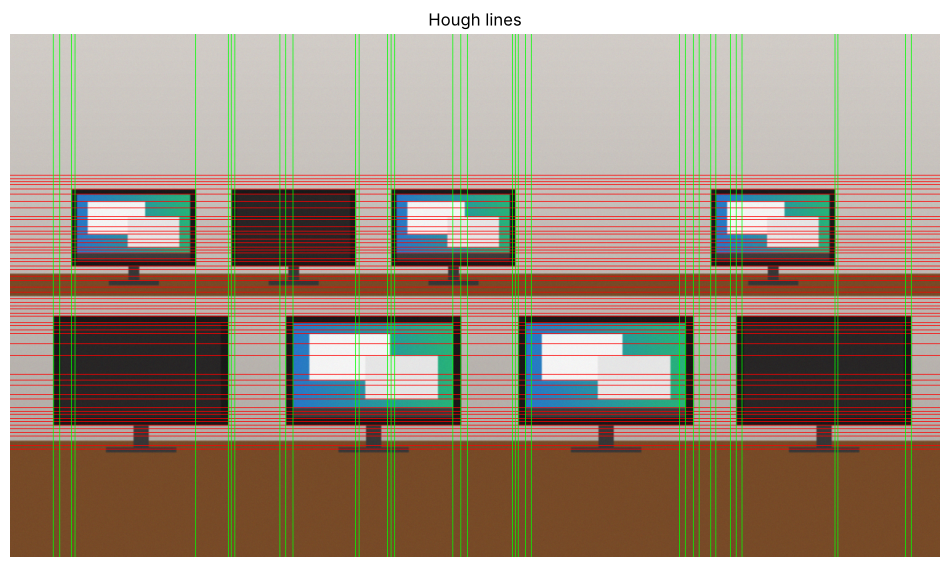

In [4]:
lines = cv2.HoughLines(edges, 1, np.pi / 180, 60)
lines = lines.reshape(-1, 2)
print("lines found:", len(lines))

ys = []
xs = []
for rho, theta in lines:
    deg = np.degrees(theta)
    if abs(deg - 90) < 2:          # horizontal
        ys.append(int(rho))
    elif deg < 2 or deg > 178:     # vertical
        xs.append(int(abs(rho)))

# remove lines that are almost same (keep strongest one)
def remove_close(vals):
    keep = []
    for v in vals:
        if all(abs(v - k) > 3 for k in keep):
            keep.append(v)
    return sorted(keep)

ys = remove_close(ys)
xs = remove_close(xs)

# desk lines go across whole image, not needed
d = cv2.dilate(edges, np.ones((5, 5), np.uint8))
ys = [y for y in ys if (d[y] > 0).mean() < 0.9]

show = rgb.copy()
for y in ys: cv2.line(show, (0, y), (W, y), (255, 0, 0), 1)
for x in xs: cv2.line(show, (x, 0), (x, H), (0, 255, 0), 1)
plt.figure(figsize=(12, 7)); plt.imshow(show); plt.title("Hough lines"); plt.axis("off"); plt.show()

### finding rectangles from lines
try every 2 horizontal + 2 vertical lines, it is a screen if all 4 sides are on edges

In [5]:
band = cv2.dilate(edges, np.ones((7, 7), np.uint8)) > 0

boxes = []
for i in range(len(ys)):
    for j in range(i + 1, len(ys)):
        y1, y2 = ys[i], ys[j]
        h = y2 - y1
        if h < 50 or h > 300:
            continue
        for a in range(len(xs)):
            for b in range(a + 1, len(xs)):
                x1, x2 = xs[a], xs[b]
                w = x2 - x1
                if w / h < 1.2 or w / h > 2.2:
                    continue
                top = band[y1, x1:x2].mean()
                bottom = band[y2, x1:x2].mean()
                left = band[y1:y2, x1].mean()
                right = band[y1:y2, x2].mean()
                if min(top, bottom, left, right) > 0.85:
                    boxes.append((x1, y1, w, h))

# if a box is inside another box remove it (screen glass inside bezel)
def inside(a, b):
    return a[0] >= b[0]-3 and a[1] >= b[1]-3 and a[0]+a[2] <= b[0]+b[2]+3 and a[1]+a[3] <= b[1]+b[3]+3

screens = []
for a in boxes:
    if not any(a != b and inside(a, b) for b in boxes):
        screens.append(a)
print("screens:", len(screens))

screens: 8


### on / off and missing screens

B1 ON 214.9
B2 OFF 40.2
B3 ON 214.9
B5 ON 214.9
F1 OFF 40.2
F2 ON 214.7
F3 ON 214.7
F4 OFF 40.2
missing screens: ['B4']


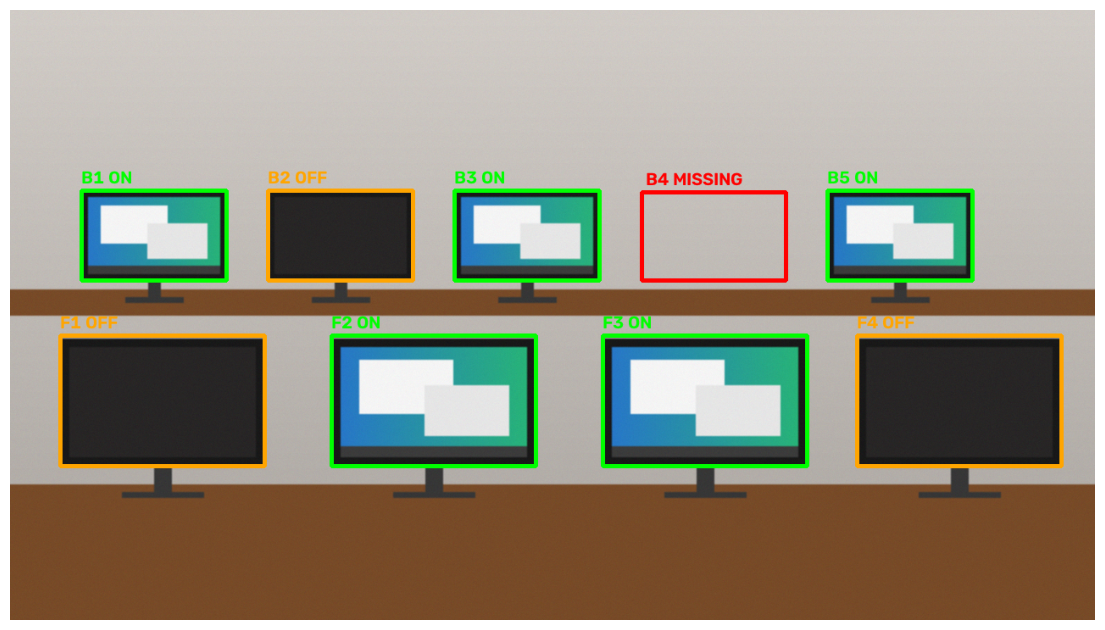

True

In [6]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
result = rgb.copy()
found = []

for (x, y, w, h) in screens:
    v = hsv[y + h//6 : y + h - h//6, x + w//6 : x + w - w//6, 2].mean()
    if v > 80:
        status = "ON"
        color = (0, 255, 0)
    else:
        status = "OFF"
        color = (255, 165, 0)
    name = "?"
    for s, (sx, sy) in seats.items():
        if x <= sx <= x + w and y <= sy <= y + h:
            name = s
    found.append(name)
    print(name, status, round(v, 1))
    cv2.rectangle(result, (x, y), (x + w, y + h), color, 3)
    cv2.putText(result, name + " " + status, (x, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

missing = [s for s in seats if s not in found]
for s in missing:
    sx, sy = seats[s]
    cv2.rectangle(result, (sx - 85, sy - 52), (sx + 85, sy + 52), (255, 0, 0), 3)
    cv2.putText(result, s + " MISSING", (sx - 80, sy - 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

print("missing screens:", missing)
plt.figure(figsize=(14, 8)); plt.imshow(result); plt.axis("off"); plt.show()
cv2.imwrite("outputs/task1_screens.png", cv2.cvtColor(result, cv2.COLOR_RGB2BGR))